<a href="https://colab.research.google.com/github/Vaishnavi2-dot/DLAIMLC_205_VAISHNAVIRAI/blob/main/DL_CASE_STUDY_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Archive:  archive.zip
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_dataset/no/27 no.jpg  
  inflating: brain_tumor_dataset/no/28 no.jpg  
  inflating: brain

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 60s 7s/step - accuracy: 0.5911 - loss: 0.8194 - val_accuracy: 0.6400 - val_loss: 0.6470
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.4729 - loss: 0.8328 - val_accuracy: 0.6200 - val_loss: 0.6415
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.5714 - loss: 0.7330 - val_accuracy: 0.6200 - val_loss: 0.6204
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.6404 - loss: 0.6459 - val_accuracy: 0.6600 - val_loss: 0.5979
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.6207 - loss: 0.6582 - val_accuracy: 0.6200 - val_loss: 0.5962
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.6502 - loss: 0.6495 - val_accuracy: 0.6400 - val_loss: 0.5935
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.6601 - loss: 0.6206 - val_accuracy: 0.7400 - val_loss: 0.5771
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.6650 - loss: 0.6158 - val_accuracy: 0.6800 - val_loss: 0.5863
Epoch 9/

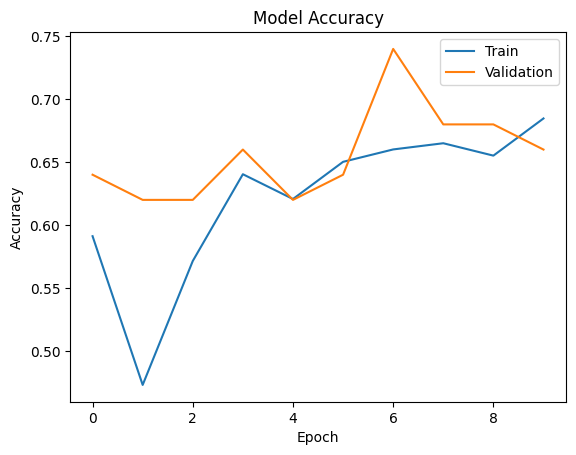

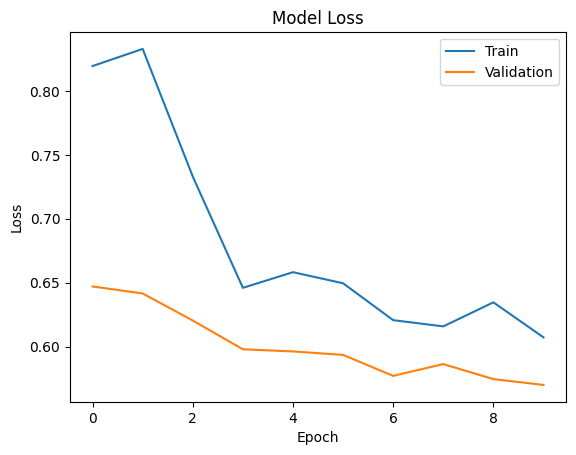

In [5]:
# =============================
# 1. Extract dataset
# =============================

!unzip archive.zip


# =============================
# 2. Import Libraries
# =============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models


# =============================
# 3. Dataset Path
# =============================

dataset_dir = "brain_tumor_dataset"


# =============================
# 4. Data Preprocessing
# =============================

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

test_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


# =============================
# 5. Load Pretrained Model
# =============================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False


# =============================
# 6. Build Model
# =============================

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.25),

    layers.Dense(1, activation='sigmoid')
])


# =============================
# 7. Compile Model
# =============================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# =============================
# 8. Train Model
# =============================

history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)


# =============================
# 9. Evaluate Model
# =============================

loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


# =============================
# 10. Plot Accuracy Graph
# =============================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()


# =============================
# 11. Plot Loss Graph
# =============================

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()